coding: utf-8
강서구 물류 최적화 시뮬레이션

#프로젝트 개요
이 노트북은 강서구의 배송 데이터를 활용하여 최적의 물류 거점과 차량 운영 방안을 도출합니다.

##주요 단계
1. 데이터 로드 (강서구 행정동 집계구 + CJ 배송출발지 거점)
2. 도로망 데이터 로드 및 거점 매핑
3. VRP(차량 경로 문제) 시뮬레이션 (용량 제약 포함)
4. 결과 분석 및 시각화

---
#2. 데이터 로드 (강서구 행정동 집계구 + CJ 배송출발지)

강서구의 행정동별 집계구 배송지 데이터(1,103개)와 CJ 대리점 4개 거점 데이터를 로드합니다.

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import sys
from IPython.display import clear_output

# 도로망 분석
import osmnx as ox
import networkx as nx
from scipy.spatial import cKDTree

# 최적화
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

print("✓ 모든 라이브러리 로드 완료")


# ## 2. 데이터 로드 (배송지 + 고정 거점)
# 
# 강서구의 배송지 데이터와 5개 고정 거점 데이터를 로드합니다.


✓ 모든 라이브러리 로드 완료


In [2]:
# 파일 경로 설정
delivery_file = '2025_Gangseo_Allocation.csv'  # 행정동별 집계구 데이터 (1103개)
depot_file = 'CJ_배송출발지_좌표.csv'  # CJ 대리점 4개 거점

# CSV 파일 안전 로드 함수
def read_csv_safe(p):
    for enc in ["utf-8-sig", "euc-kr", "cp949"]:
        try:
            df = pd.read_csv(p, encoding=enc)
            df.columns = df.columns.str.strip()
            return df
        except UnicodeDecodeError:
            continue
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    return df

# 강서구 행정동별 집계구 배송지 데이터 로드 (CSV 파일)
df_deliveries = read_csv_safe(delivery_file)

# 데이터 확인
print(f"총 배송지(집계구) 수: {len(df_deliveries):,}개")
print(f"\n컬럼 목록: {df_deliveries.columns.tolist()}")
if '집계구별_물동량' in df_deliveries.columns:
    print(f"총 물동량: {df_deliveries['집계구별_물동량'].sum():,.0f}kg")
print(f"\n데이터 샘플:")
df_deliveries.head()


총 배송지(집계구) 수: 1,103개

컬럼 목록: ['행정동명', '집계구코드', '위도', '경도', '집계구별_물동량', '가중치', '총가구수', '총인구수']
총 물동량: 67,362kg

데이터 샘플:


,행정동명,집계구코드,위도,경도,집계구별_물동량,가중치,총가구수,총인구수
0,가양1동,1.116080e+13,37.568229,126.840086,292,0.004340,2108,2385
1,가양1동,1.116080e+13,37.567480,126.827102,259,0.003850,1901,2116
2,가양1동,1.116080e+13,37.560010,126.828464,227,0.003370,1645,1852
3,가양1동,1.116080e+13,37.564929,126.839827,213,0.003168,1566,1741
4,가양1동,1.116080e+13,37.568921,126.825806,200,0.002968,1448,1631


In [3]:
if '위도' not in df_deliveries.columns or '경도' not in df_deliveries.columns:
    raise KeyError("필수 칼럼(위도, 경도)이 배송지 데이터에 없습니다.")

df_deliveries['위도'] = pd.to_numeric(df_deliveries['위도'], errors='coerce')
df_deliveries['경도'] = pd.to_numeric(df_deliveries['경도'], errors='coerce')

# 유효한 좌표만 사용
df_valid_coords = df_deliveries.dropna(subset=['위도', '경도'])

print(f"\n배송지 데이터 (행정동별 집계구):")
print(f"  - 총 집계구: {len(df_deliveries):,}개")
print(f"  - 유효 좌표: {len(df_valid_coords):,}개")
print(f"  - 무효 좌표: {len(df_deliveries) - len(df_valid_coords):,}개")

# CJ 배송출발지 데이터 로드
df_depots = read_csv_safe(depot_file)

# CJ 거점 데이터 검증
if '위도' not in df_depots.columns or '경도' not in df_depots.columns:
    raise KeyError(f"{depot_file}에 필수 칼럼(위도, 경도)이 없습니다.")

df_depots['위도'] = pd.to_numeric(df_depots['위도'], errors='coerce')
df_depots['경도'] = pd.to_numeric(df_depots['경도'], errors='coerce')
df_depots = df_depots.dropna(subset=['위도', '경도'])  # 유효한 CJ 거점만 사용

print(f"\nCJ 배송출발지 데이터:")
print(f"  - 총 거점: {len(df_depots)}개")
for idx, row in df_depots.iterrows():
    depot_name = row.get('이름', f"거점{idx+1}")
    print(f"  {idx+1}. {depot_name}")
    print(f"     주소: {row.get('주소', 'N/A')}")
    print(f"     위치: 위도 {row['위도']:.6f}, 경도 {row['경도']:.6f}")


# **중요**: CJ 배송출발지와 배송지가 모두 강서구에 위치하므로 **강서구 도로망**을 로드합니다.
# 
# - **배송출발지 위치**: 강서구 (CJ 대리점 4개 거점)
# - **배송지 위치**: 강서구 (1,103개 행정동별 집계구)
# - **도로망 범위**: 강서구
# 

# ⏱️ **첫 실행 시 주의**: 강서구 도로망 다운로드는 1-2분 정도 소요됩니다.


배송지 데이터 (행정동별 집계구):
  - 총 집계구: 1,103개
  - 유효 좌표: 1,103개
  - 무효 좌표: 0개

CJ 배송출발지 데이터:
  - 총 거점: 4개
  1. 뉴마곡
     주소: 서울 강서구 공항대로 220 1003호
     위치: 위도 37.558704, 경도 126.831766
  2. 본동/보라매
     주소: 서울 강서구 양천로 584 201호
     위치: 위도 37.555897, 경도 126.863486
  3. 서울건영
     주소: 서울 강서구 양천로 373 제일제당내 씨제이대한
     위치: 위도 37.566958, 경도 126.843398
  4. 화곡제일
     주소: 서울 강서구 양천로 590 103동909호
     위치: 위도 37.555792, 경도 126.864432


In [4]:
# 4. 강서구 도로망 데이터 로드 
place_name = 'Gangseo-gu, Seoul, South Korea'
graph_path = 'gangseo_drive_network.graphml'

try:
    G = ox.load_graphml(graph_path)
    print(f"✓ '{graph_path}' 파일에서 도로망 데이터를 불러왔습니다.")
except FileNotFoundError:
    print(f"'{graph_path}' 파일이 없어 새로 다운로드합니다...")
    print("⚠️ 강서구 도로망 다운로드 중입니다 (1-2분 소요)...")
    G = ox.graph_from_place(place_name, network_type='drive')
    ox.save_graphml(G, graph_path)
    print(f"✓ 도로망 데이터를 '{graph_path}'에 저장했습니다.")

print(f"\n도로망 정보:")
print(f"  - 노드(교차로) 수: {len(G.nodes):,}개")
print(f"  - 엣지(도로) 수: {len(G.edges):,}개")
print(f"  - 범위: 강서구 (CJ 배송출발지 거점 + 행정동 집계구 모두 포함)")


✓ 'gangseo_drive_network.graphml' 파일에서 도로망 데이터를 불러왔습니다.

도로망 정보:
  - 노드(교차로) 수: 2,626개
  - 엣지(도로) 수: 7,535개
  - 범위: 강서구 (CJ 배송출발지 거점 + 행정동 집계구 모두 포함)


In [5]:
# CJ 배송출발지 4개 거점을 도로망의 가장 가까운 노드로 매핑
depot_nodes = ox.distance.nearest_nodes(G, X=df_depots['경도'], Y=df_depots['위도'])
depot_nodes_list = depot_nodes.tolist() if hasattr(depot_nodes, 'tolist') else list(depot_nodes)

print(f"\nCJ 배송출발지 거점 매핑 결과 (도로망 노드):")
for i, (depot_id, row) in enumerate(zip(depot_nodes_list, df_depots.itertuples())):
    node_info = G.nodes[depot_id]
    depot_name = getattr(row, '이름', f"거점{i+1}")
    print(f"{i+1}. {depot_name}")
    print(f"   노드 ID: {depot_id}")
    print(f"   원본 좌표: ({row.위도:.6f}, {row.경도:.6f})")
    print(f"   매핑된 좌표: ({node_info['y']:.6f}, {node_info['x']:.6f})\n")


# ### 도로망 시각화 (선택 사항)
# 
# 강서구 도로망의 구조를 확인해봅니다. 전체 네트워크가 복잡하므로 일부 영역만 표시합니다.



CJ 배송출발지 거점 매핑 결과 (도로망 노드):
1. 뉴마곡
   노드 ID: 4872343798
   원본 좌표: (37.558704, 126.831766)
   매핑된 좌표: (37.559040, 126.832526)

2. 본동/보라매
   노드 ID: 3042644553
   원본 좌표: (37.555897, 126.863486)
   매핑된 좌표: (37.555821, 126.863203)

3. 서울건영
   노드 ID: 5818339840
   원본 좌표: (37.566958, 126.843398)
   매핑된 좌표: (37.566843, 126.844263)

4. 화곡제일
   노드 ID: 4605033168
   원본 좌표: (37.555792, 126.864432)
   매핑된 좌표: (37.556203, 126.864301)



✓ 도로망 시각화 저장 완료: 강서구_도로망_구조.png


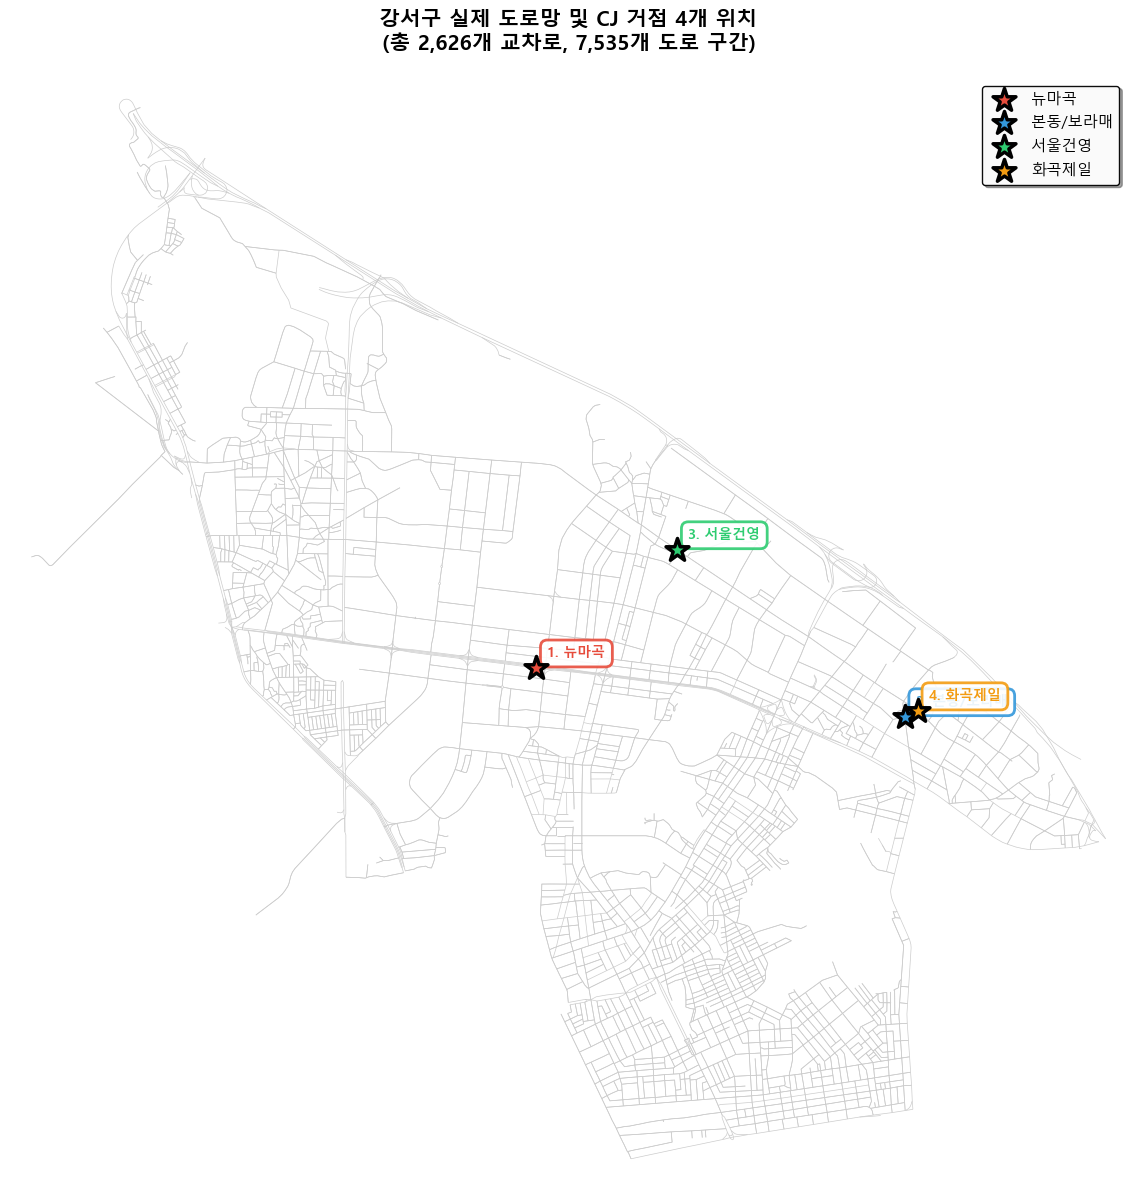


도로망 통계:
  - 전체 노드(교차로): 2,626개
  - 전체 엣지(도로): 7,535개
  - 주요 교차로 (degree≥4): 2,261개
  - 평균 연결도: 5.74

CJ 거점 위치:
  1. 뉴마곡: 위도 37.559040, 경도 126.832526
  2. 본동/보라매: 위도 37.555821, 경도 126.863203
  3. 서울건영: 위도 37.566843, 경도 126.844263
  4. 화곡제일: 위도 37.556203, 경도 126.864301


In [6]:
# 도로망 시각화 (OSMnx를 사용한 실제 도로망 표시)
fig, ax = plt.subplots(figsize=(16, 12))

# OSMnx의 plot_graph 함수로 실제 도로망 시각화
ox.plot_graph(G, ax=ax, node_size=0, edge_color='#cccccc', edge_linewidth=0.5, 
              bgcolor='white', show=False, close=False)

# CJ 거점 4개만 사용 (색상도 4개로 조정)
depot_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# CJ 거점을 도로망에 표시
for i, depot_id in enumerate(depot_nodes_list):
    depot_lat = G.nodes[depot_id]['y']
    depot_lon = G.nodes[depot_id]['x']
    depot_name = df_depots.iloc[i].get('이름', f'거점{i+1}')
    
    # 거점 위치를 별표 마커로 표시
    ax.scatter(depot_lon, depot_lat, c=depot_colors[i], s=300, marker='*', 
              edgecolors='black', linewidth=2.5, zorder=10, label=f'{depot_name}')
    
    # 거점 이름을 텍스트로 표시
    ax.annotate(f'{i+1}. {depot_name}', (depot_lon, depot_lat), 
               xytext=(8, 8), textcoords='offset points', 
               fontsize=10, fontweight='bold', color=depot_colors[i],
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                        edgecolor=depot_colors[i], linewidth=2, alpha=0.9))

# 그래프 축 및 제목 설정
ax.set_xlabel('경도 (Longitude)', fontsize=13, fontweight='bold')
ax.set_ylabel('위도 (Latitude)', fontsize=13, fontweight='bold')
ax.set_title(f'강서구 실제 도로망 및 CJ 거점 {len(depot_nodes_list)}개 위치\n'
            f'(총 {len(G.nodes):,}개 교차로, {len(G.edges):,}개 도로 구간)', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95, 
         edgecolor='black', fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# 축 눈금 포맷 (위도/경도 좋은 가독성)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('강서구_도로망_구조.png', dpi=250, bbox_inches='tight')
print("✓ 도로망 시각화 저장 완료: 강서구_도로망_구조.png")
plt.show()

# 도로망 통계 계산
node_degrees = dict(G.degree())
major_nodes = [node for node, degree in node_degrees.items() if degree >= 4]

print(f"\n도로망 통계:")
print(f"  - 전체 노드(교차로): {len(G.nodes):,}개")
print(f"  - 전체 엣지(도로): {len(G.edges):,}개")
print(f"  - 주요 교차로 (degree≥4): {len(major_nodes):,}개")
print(f"  - 평균 연결도: {sum(node_degrees.values())/len(node_degrees):.2f}")
print(f"\nCJ 거점 위치:")
for i, depot_id in enumerate(depot_nodes_list):
    depot_name = df_depots.iloc[i].get('이름', f'거점{i+1}')
    depot_lat = G.nodes[depot_id]['y']
    depot_lon = G.nodes[depot_id]['x']
    print(f"  {i+1}. {depot_name}: 위도 {depot_lat:.6f}, 경도 {depot_lon:.6f}")


# ## 4. 시뮬레이션 파라미터 설정 및 배송지 샘플링

In [7]:
# 차량 정보 설정
vehicles = {
    'LPG_1t': {
        'name': '1톤 LPG 트럭 (포터 II)',
        'fuel_efficiency': 6.6,      # km/L (실연비)
        'co2_per_liter': 0.357,      # kg CO2/L (LPG 배출계수)
        'fuel_price': 995.25,        # 원/L (LPG 가격)
        'cost_per_km': 995.25 / 6.6, # 원/km (유류비: 가격/연비)
        'capacity': 1000,            # kg (최대 적재 용량)
    }
}

# 비용 파라미터
current_carbon_tax_per_kg_co2 = 10.55  # 원/kg CO2 (한국 ETS 평균)
driver_wage_per_hour = 18000  # 시간당 인건비 (원/시간)
avg_speed_kph = 35  # 평균 주행 속도 (km/h, 도심 배송)
driver_wage_per_km = driver_wage_per_hour / avg_speed_kph  # km당 인건비

print("차량 정보:")
for key, vehicle in vehicles.items():
    print(f"\n  {vehicle['name']}")
    print(f"    - 연비: {vehicle['fuel_efficiency']} km/L")
    print(f"    - LPG 가격: {vehicle['fuel_price']:.2f}원/L")
    print(f"    - CO2 배출계수: {vehicle['co2_per_liter']} kg/L")
    print(f"    - 유류비: {vehicle['cost_per_km']:.2f}원/km")
    print(f"    - 인건비: {driver_wage_per_km:.2f}원/km")
    print(f"    - 총 운행 비용: {vehicle['cost_per_km'] + driver_wage_per_km:.2f}원/km")
    print(f"    - 적재 용량: {vehicle['capacity']}kg")

print(f"\n탄소세: {current_carbon_tax_per_kg_co2}원/kg CO2")
print(f"km당 탄소 비용: {vehicles['LPG_1t']['co2_per_liter'] / vehicles['LPG_1t']['fuel_efficiency'] * current_carbon_tax_per_kg_co2:.2f}원/km")



차량 정보:

  1톤 LPG 트럭 (포터 II)
    - 연비: 6.6 km/L
    - LPG 가격: 995.25원/L
    - CO2 배출계수: 0.357 kg/L
    - 유류비: 150.80원/km
    - 인건비: 514.29원/km
    - 총 운행 비용: 665.08원/km
    - 적재 용량: 1000kg

탄소세: 10.55원/kg CO2
km당 탄소 비용: 0.57원/km


In [8]:
# 배송지 수요량 설정
# 강서구 행정동별 집계구 1,103개 전체 사용
# CSV 파일의 '집계구별_물동량' 칼럼에서 실제 물동량(kg) 가져오기

print("="*80)
print("배송지 데이터 로드 (전체 집계구)")
print("="*80)

# 전체 데이터 사용
df_sample = df_valid_coords.copy()
print(f"✓ 강서구 전체 집계구 사용: {len(df_sample):,}개")

# CSV 파일에서 실제 물동량(kg) 가져오기
if '집계구별_물동량' in df_sample.columns:
    df_sample['수요량'] = df_sample['집계구별_물동량'].fillna(0).astype(int)
else:
    raise KeyError("'집계구별_물동량' 칼럼이 데이터에 없습니다. CSV 파일을 확인하세요.")

# 배송지를 도로망 노드로 매핑
delivery_nodes = ox.distance.nearest_nodes(G, X=df_sample['경도'], Y=df_sample['위도'])
demands = df_sample['수요량'].tolist()

# 통계 계산
vehicle_capacity = vehicles['LPG_1t']['capacity']  # 1000 kg
total_demand = sum(demands)
theoretical_min_vehicles = int(np.ceil(total_demand / vehicle_capacity))

print(f"\n배송지 정보 (실제 물동량 기반):")
print(f"  - 총 집계구: {len(df_sample):,}개")
print(f"  - 총 물동량: {total_demand:,.0f}kg")
print(f"  - 평균 물동량: {np.mean(demands):.1f}kg/집계구")
print(f"  - 최소 물동량: {min(demands):,}kg")
print(f"  - 최대 물동량: {max(demands):,}kg")
print(f"  - 중앙값: {np.median(demands):.0f}kg")
print(f"  - 표준편차: {np.std(demands):.1f}kg")

print(f"\n차량 운영 계획:")
print(f"  - 차량 적재 용량: {vehicle_capacity:,}kg/대")
print(f"  - 이론적 최소 차량: {theoretical_min_vehicles}대")
print(f"  - CJ 거점 수: {len(df_depots)}개")
print(f"  - 거점당 평균 차량: {theoretical_min_vehicles/len(df_depots):.1f}대")
print(f"  - 목표: CJ {len(df_depots)}개 거점에 {theoretical_min_vehicles}~{theoretical_min_vehicles+5}대 균형 배치")

print(f"\n✓ 전체 {len(df_sample):,}개 집계구에 대한 최적 배송 경로를 계산합니다.")


# ## 4-1. 거리 행렬 사전 계산 (성능 최적화)
# 
# 모든 노드 간 거리를 한 번에 계산하여 이후 빠른 조회가 가능하도록 합니다.

배송지 데이터 로드 (전체 집계구)
✓ 강서구 전체 집계구 사용: 1,103개

배송지 정보 (실제 물동량 기반):
  - 총 집계구: 1,103개
  - 총 물동량: 67,362kg
  - 평균 물동량: 61.1kg/집계구
  - 최소 물동량: 4kg
  - 최대 물동량: 292kg
  - 중앙값: 60kg
  - 표준편차: 17.8kg

차량 운영 계획:
  - 차량 적재 용량: 1,000kg/대
  - 이론적 최소 차량: 68대
  - CJ 거점 수: 4개
  - 거점당 평균 차량: 17.0대
  - 목표: CJ 4개 거점에 68~73대 균형 배치

✓ 전체 1,103개 집계구에 대한 최적 배송 경로를 계산합니다.


In [9]:
print("\n" + "="*80)
print("거리 행렬 사전 계산 중 (성능 최적화: single_source_dijkstra 사용)")
print("="*80)

# 모든 노드 통합 (거점 + 배송지)
all_nodes = depot_nodes_list + list(delivery_nodes)
num_total_nodes = len(all_nodes)

print(f"총 노드 수: {num_total_nodes}개 (거점 {len(depot_nodes_list)}개 + 배송지 {len(delivery_nodes)}개)")
print(f"계산할 출발 노드 개수: {num_total_nodes}개")  # Dijkstra를 num_total_nodes 번만 수행
print("※ 기존 N^2회 shortest_path_length 호출 → N회 Dijkstra로 축소")

# 거리 행렬 생성 (기본값은 '연결 불가' 값으로 채우기)
INF = 999999.0
distance_matrix_global = np.full((num_total_nodes, num_total_nodes), INF, dtype=np.float32)
np.fill_diagonal(distance_matrix_global, 0.0)  # 자기 자신까지 거리는 0

import time
start_time = time.time()

for i, src_node in enumerate(all_nodes):
    # 1) src_node를 출발점으로 한 번만 Dijkstra 수행
    lengths = nx.single_source_dijkstra_path_length(G, src_node, weight="length")
    # lengths: {node_id: distance_in_meters, ...}

    # 2) 내가 관심 있는 노드들(all_nodes)에 대해서만 matrix 채우기
    for j, dst_node in enumerate(all_nodes):
        if i == j:
            continue
        if dst_node in lengths:
            distance_matrix_global[i, j] = lengths[dst_node] / 1000.0  # m → km
        # else는 그대로 INF 유지 (연결 불가)

    # 진행률 표시 (10개마다)
    if (i + 1) % 10 == 0 or i == num_total_nodes - 1:
        elapsed = time.time() - start_time
        progress = (i + 1) / num_total_nodes * 100
        print(f"  진행: {i+1}/{num_total_nodes} ({progress:.1f}%) - 경과 시간: {elapsed:.1f}초")

elapsed_time = time.time() - start_time
print(f"\n✓ 거리 행렬 계산 완료! (single_source_dijkstra 활용)")
print(f"  총 소요 시간: {elapsed_time:.2f}초")
print(f"  메모리 사용: {distance_matrix_global.nbytes / 1024:.1f} KB")
valid_mask = distance_matrix_global < INF
print(f"  평균 거리: {distance_matrix_global[valid_mask].mean():.2f} km")
print("="*80)



거리 행렬 사전 계산 중 (성능 최적화: single_source_dijkstra 사용)
총 노드 수: 1107개 (거점 4개 + 배송지 1103개)
계산할 출발 노드 개수: 1107개
※ 기존 N^2회 shortest_path_length 호출 → N회 Dijkstra로 축소
  진행: 10/1107 (0.9%) - 경과 시간: 0.1초
  진행: 10/1107 (0.9%) - 경과 시간: 0.1초
  진행: 20/1107 (1.8%) - 경과 시간: 0.2초
  진행: 30/1107 (2.7%) - 경과 시간: 0.3초
  진행: 20/1107 (1.8%) - 경과 시간: 0.2초
  진행: 30/1107 (2.7%) - 경과 시간: 0.3초
  진행: 40/1107 (3.6%) - 경과 시간: 0.4초
  진행: 40/1107 (3.6%) - 경과 시간: 0.4초
  진행: 50/1107 (4.5%) - 경과 시간: 0.6초
  진행: 60/1107 (5.4%) - 경과 시간: 0.7초
  진행: 50/1107 (4.5%) - 경과 시간: 0.6초
  진행: 60/1107 (5.4%) - 경과 시간: 0.7초
  진행: 70/1107 (6.3%) - 경과 시간: 0.8초
  진행: 70/1107 (6.3%) - 경과 시간: 0.8초
  진행: 80/1107 (7.2%) - 경과 시간: 0.9초
  진행: 90/1107 (8.1%) - 경과 시간: 1.0초
  진행: 80/1107 (7.2%) - 경과 시간: 0.9초
  진행: 90/1107 (8.1%) - 경과 시간: 1.0초
  진행: 100/1107 (9.0%) - 경과 시간: 1.1초
  진행: 100/1107 (9.0%) - 경과 시간: 1.1초
  진행: 110/1107 (9.9%) - 경과 시간: 1.2초
  진행: 120/1107 (10.8%) - 경과 시간: 1.3초
  진행: 110/1107 (9.9%) - 경과 시간: 1.2초
  진행: 120/1107 (10.8%) - 경과 시간: 

In [10]:
def get_distance_km(from_node, to_node):
    """
    사전 계산된 거리 행렬에서 두 노드 간 거리 조회
    
    Args:
        from_node: 출발 노드 ID
        to_node: 도착 노드 ID
    
    Returns:
        float: 거리(km) 또는 999999 (연결 불가)
    """
    try:
        i = all_nodes.index(from_node)
        j = all_nodes.index(to_node)
        return distance_matrix_global[i][j]
    except ValueError:
        # 노드가 all_nodes 리스트에 없는 경우 (예외 상황)
        print(f"  ⚠️ 경고: 노드 {from_node} 또는 {to_node}를 찾을 수 없습니다.")
        return 999999

def create_cost_matrix(vrp_nodes, vehicle_type, tax_rate_per_kg):
    """
    노드 간 이동 비용 매트릭스 생성 (사전 계산된 거리 행렬 활용)

    비용 구성: 운행비용(유류+인건비) + 탄소세

    Args:
        vrp_nodes: 노드 ID 리스트 (거점 + 배송지)
        vehicle_type: 차량 종류 ('LPG_1t')
        tax_rate_per_kg: kg당 탄소세 (원/kgCO2)

    Returns:
        numpy.ndarray: N×N 비용 매트릭스 (int32)
    """
    num_nodes = len(vrp_nodes)
    cost_matrix = np.zeros((num_nodes, num_nodes), dtype=np.int32)
    vehicle = vehicles[vehicle_type]

    # CO2 배출량 계산
    if 'co2_per_liter' in vehicle:
        co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    else:
        kwh_per_km = 1 / vehicle['energy_efficiency']
        co2_per_km = vehicle['co2_per_kwh'] * kwh_per_km

    # 비용 매트릭스 계산 (사전 계산된 거리 행렬에서 즉시 조회)
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j: 
                continue
            
            # 사전 계산된 거리 행렬에서 조회 (빠름!)
            distance_km = get_distance_km(vrp_nodes[i], vrp_nodes[j])
            
            if distance_km >= 999999:  # 연결 불가
                cost_matrix[i][j] = 99999  # 오버플로우 방지
                continue

            operational_cost = (vehicle['cost_per_km'] + driver_wage_per_km) * distance_km
            carbon_cost = (co2_per_km * tax_rate_per_kg) * distance_km
            total_cost = operational_cost + carbon_cost

            # 직접 정수로 변환 (스케일링 불필요 - 강서구 내부 배송)
            cost_matrix[i][j] = int(total_cost)
            if cost_matrix[i][j] == 0:  # 0이 되지 않도록 최소값 보장
                cost_matrix[i][j] = 1

    return cost_matrix

print("✓ 비용 매트릭스 생성 함수 정의 완료")


# ## 5-2. MDCVRP (Multi-Depot Capacitated VRP) 유틸리티 함수
# 
# MDCVRP 최적화에 필요한 보조 함수들을 정의합니다.


✓ 비용 매트릭스 생성 함수 정의 완료


In [11]:
def calculate_min_vehicles(total_demand, vehicle_capacity):
    """
    수요량과 용량을 기반으로 필요한 최소 차량 대수를 계산합니다.

    Args:
        total_demand (float): 총 수요량 (kg)
        vehicle_capacity (int): 차량 용량 (kg)

    Returns:
        int: 이론적 최소 필요 차량 대수

    Example:
        >>> calculate_min_vehicles(350, 20)
        18
    """
    if vehicle_capacity <= 0:
        return 0
    return int(np.ceil(total_demand / vehicle_capacity))

print("✓ MDCVRP 유틸리티 함수 정의 완료")


✓ MDCVRP 유틸리티 함수 정의 완료


---
# 3. 휴리스틱 방법론

휴리스틱 접근법은 2단계로 구성됩니다:
1. **거점 할당**: 각 배송지를 유클리드 거리가 가장 가까운 거점에 할당
2. **개별 CVRP**: 각 거점별로 독립적인 용량 제약 차량 경로 문제(CVRP) 해결

빠른 실행 속도를 가지지만, 거점 간 협업을 고려하지 않아 준최적해를 제공합니다.

In [ ]:
def solve_vrp(cost_matrix, num_vehicles, demands, vehicle_capacity, return_routes=False):
    """
    단일 거점 CVRP 솔버 (휴리스틱 비교용)
    
    용량 제약이 있는 VRP 문제를 해결합니다 (Capacitated VRP).
    NOTE: MDCVRP 휴리스틱 비교를 위해서만 사용됩니다.

    Args:
        cost_matrix: 노드 간 이동 비용 매트릭스
        num_vehicles: 사용할 차량 대수
        demands: 각 노드(배송지)의 수요량 리스트 (인덱스 0은 거점이므로 0)
        vehicle_capacity: 각 차량의 최대 적재 용량
        return_routes: True이면 (비용, 경로정보) 반환, False이면 비용만 반환

    Returns:
        return_routes=False: 총 물류비용 (원)
        return_routes=True: (총 물류비용, 차량별 경로 리스트)
    """
    manager = pywrapcp.RoutingIndexManager(len(cost_matrix), num_vehicles, 0)
    routing = pywrapcp.RoutingModel(manager)

    # Cost callback
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return cost_matrix[from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Demand callback
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return demands[from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    # Add capacity constraint
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,
        [vehicle_capacity] * num_vehicles,
        True,
        'Capacity'
    )

    # 탐색 파라미터 설정
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 600  # 타임아웃 증가 (60→180초): 복잡한 거점 문제 해결용
    search_parameters.log_search = False

    # Solve
    solution = routing.SolveWithParameters(search_parameters)
    if solution:
        total_cost = solution.ObjectiveValue()

        if return_routes:
            routes = []
            for vehicle_id in range(num_vehicles):
                route = []
                index = routing.Start(vehicle_id)
                while not routing.IsEnd(index):
                    node_index = manager.IndexToNode(index)
                    route.append(node_index)
                    index = solution.Value(routing.NextVar(index))
                route.append(manager.IndexToNode(index))
                if len(route) > 2:
                    routes.append(route)
            return total_cost, routes
        else:
            return total_cost

    if return_routes:
        return None, []
    return None

print("✓ CVRP 솔버 함수 정의 완료 (휴리스틱 용)")


✓ CVRP 솔버 함수 정의 완료 (MDCVRP 휴리스틱 비교용)


---
# 4. OR-Tools MDCVRP 방법론

OR-Tools 기반 통합 최적화는 다음과 같은 특징을 가집니다:
- **통합 최적화**: 거점 할당과 차량 경로를 동시에 최적화 (글로벌 최적화)
- **용량 제약**: 각 차량의 최대 적재량 고려
- **다중 거점**: 여러 거점에서 독립적으로 차량 출발 및 복귀
- **최적해 지향**: 휴리스틱보다 더 나은 해를 찾지만 실행 시간이 더 길 수 있음

In [ ]:
def solve_heuristic(depot_nodes_list, depot_names, delivery_nodes_list, delivery_coords, 
                    demands_list, vehicle_type='LPG_1t', tax_rate_per_kg=50):
    """
    휴리스틱 기반 배송 최적화 솔버 (2단계 접근법)

    방식:
    1. 각 배송지를 가장 가까운 거점에 할당 (유클리드 거리)
    2. 각 거점별로 독립적인 CVRP 실행

    Returns:
        tuple: (거점별 결과 dict, 총 비용, 총 차량 수)
    """
    from scipy.spatial.distance import cdist

    vehicle = vehicles[vehicle_type]
    vehicle_capacity = vehicle['capacity']
    num_depots = len(depot_nodes_list)

    print("\n" + "="*80)
    print("휴리스틱 기반 배송 경로 최적화")
    print("방식:\n1. 각 배송지를 가장 가까운 거점에 할당 (유클리드 거리)\n2. 각 거점별로 독립적인 CVRP 실행")
    print("="*80)

    # 1단계: 유클리드 거리 기반으로 배송지를 거점에 할당
    depot_coords = []
    for depot_node in depot_nodes_list:
        node_info = G.nodes[depot_node]
        depot_coords.append([node_info['y'], node_info['x']])

    depot_coords = np.array(depot_coords)
    customer_coords = np.array(delivery_coords)

    distances = cdist(customer_coords, depot_coords, metric='euclidean')
    assignments = {depot: [] for depot in depot_nodes_list}

    for cust_idx in range(len(delivery_nodes_list)):
        nearest_depot_idx = np.argmin(distances[cust_idx])
        assigned_depot = depot_nodes_list[nearest_depot_idx]
        assignments[assigned_depot].append(cust_idx)

    print(f"1단계: 최근접 거점 할당 완료")
    
    # 할당 상태 진단 출력
    print(f"\n[거점별 할당 상태]")
    for depot_idx, depot_node in enumerate(depot_nodes_list):
        assigned = assignments[depot_node]
        if len(assigned) > 0:
            demand = sum([demands_list[idx] for idx in assigned])
            vehicles_needed = max(1, int(np.ceil(demand / vehicle_capacity)))
            print(f"  거점 {depot_idx+1} ({depot_names[depot_idx]}): 배송지 {len(assigned)}개, 수요량 {demand:.0f}kg, 필요 차량 {vehicles_needed}대")

    # 2단계: 각 거점별로 CVRP 해결
    print(f"\n2단계: 거점별 CVRP 최적화 중...")

    results = {}
    total_cost = 0
    total_vehicles = 0

    for depot_idx, depot_node in enumerate(depot_nodes_list):
        assigned_customers = assignments[depot_node]

        if len(assigned_customers) == 0:
            results[depot_node] = {
                'depot_name': depot_names[depot_idx],
                'depot_node': depot_node,
                'num_customers': 0,
                'customer_indices': [],
                'total_demand': 0,
                'num_vehicles': 0,
                'total_cost': 0,
                'routes': []
            }
            continue

        # 이 거점의 CVRP 노드: [거점] + [할당된 배송지들]
        vrp_nodes = [depot_node] + [delivery_nodes_list[idx] for idx in assigned_customers]
        vrp_demands = [0] + [demands_list[idx] for idx in assigned_customers]

        # 비용 매트릭스 생성
        cost_matrix = create_cost_matrix(vrp_nodes, vehicle_type, tax_rate_per_kg)

        # 필요한 차량 수 계산
        depot_demand = sum([demands_list[idx] for idx in assigned_customers])
        num_vehicles_needed = max(1, int(np.ceil(depot_demand / vehicle_capacity)))

        # CVRP 해결
        vrp_cost, routes = solve_vrp(cost_matrix, num_vehicles_needed, vrp_demands, 
                                     vehicle_capacity, return_routes=True)

        if vrp_cost is None:
            print(f"  [거점 {depot_idx+1}] {depot_names[depot_idx]}: CVRP 해결 실패")
            print(f"    → 원인: 180초 타임아웃 내에 해를 찾지 못했습니다.")
            print(f"    → 배송지: {len(assigned_customers)}개, 수요량: {depot_demand:.0f}kg, 할당 차량: {num_vehicles_needed}대")
            continue

        results[depot_node] = {
            'depot_name': depot_names[depot_idx],
            'depot_node': depot_node,
            'num_customers': len(assigned_customers),
            'customer_indices': assigned_customers,
            'total_demand': depot_demand,
            'num_vehicles': len(routes),
            'total_cost': vrp_cost,
            'routes': routes,
            'avg_cost_per_vehicle': vrp_cost / len(routes) if routes else 0
        }

        total_cost += vrp_cost
        total_vehicles += len(routes)

        print(f"  [거점 {depot_idx+1}] {depot_names[depot_idx]}: "
              f"{len(assigned_customers)}개 배송지, {len(routes)}대 차량, {vrp_cost:,.0f}원")

    # 결과 출력
    print("\n" + "="*80)
    print("휴리스틱 MDCVRP 완료")
    print("="*80)
    print(f"총 비용: {total_cost:,.0f}원")
    print(f"총 차량: {total_vehicles}대")
    print("="*80)

    return results, int(total_cost), total_vehicles

print("✓ 휴리스틱 배송 최적화 솔버 정의 완료")


✓ 휴리스틱 배송 최적화 솔버 정의 완료


In [14]:
def solve_mdcvrp_ortools(depot_nodes_list, depot_names, delivery_nodes_list, delivery_coords, 
                         demands_list, vehicle_type='LPG_1t', tax_rate_per_kg=50):
    """
    MDCVRP OR-Tools 통합 최적화 솔버 (Multi-Depot Capacitated VRP)

    🎯 핵심 개념:
    - 고객 할당과 차량 경로를 동시에 최적화 (2단계 → 1단계 통합)
    - 각 거점에서 독립적으로 차량 출발/복귀
    - 총 물류비용 최소화를 목적함수로 설정

    📊 최적화 과정:
    1. 통합 비용 매트릭스 생성 (모든 거점 + 모든 배송지)
    2. OR-Tools Multi-Depot VRP 모델 구성
    3. 동시 최적화 실행 (고객 할당 + 경로 계획)
    4. 거점별 결과 분석 및 반환

    Args:
        depot_nodes_list: 거점 노드 ID 리스트
        depot_names: 거점 이름 리스트
        delivery_nodes_list: 배송지 노드 ID 리스트  
        delivery_coords: 배송지 좌표 리스트 [(lat, lon), ...]
        demands_list: 배송지별 수요량 리스트
        vehicle_type: 차량 종류
        tax_rate_per_kg: 탄소세율

    Returns:
        tuple: (거점별 결과 dict, 총 비용, 총 차량 수)
    """
    vehicle = vehicles[vehicle_type]
    vehicle_capacity = vehicle['capacity']
    num_depots = len(depot_nodes_list)
    num_customers = len(delivery_nodes_list)

    # 총 수요량 기반 이론적 최소 차량 계산
    total_demand = sum(demands_list)
    theoretical_min_vehicles = int(np.ceil(total_demand / vehicle_capacity))

    # 거점당 최대 차량 계산: 이론적 최소의 150% / 거점 수 (여유분)
    VEHICLE_CAPACITY_MULTIPLIER = 1.5  # 150% 여유분
    MIN_VEHICLES_PER_DEPOT = 5  # 거점당 최소 차량
    max_vehicles_per_depot = max(MIN_VEHICLES_PER_DEPOT, 
                                 int(np.ceil(theoretical_min_vehicles * VEHICLE_CAPACITY_MULTIPLIER / num_depots)))
    total_vehicles = num_depots * max_vehicles_per_depot

    print("\n" + "="*80)
    print("Multi-Depot Capacitated VRP 최적화 (OR-Tools 기반)")
    print("="*80)
    print(f"거점 수: {num_depots}개")
    print(f"배송지 수: {num_customers}개")
    print(f"총 수요량: {total_demand:.0f} kg")
    print(f"차량 용량: {vehicle_capacity} kg")
    print(f"이론적 최소 차량: {theoretical_min_vehicles}대")
    print(f"거점당 최대 차량: {max_vehicles_per_depot}대 (동적 계산)")
    print(f"총 가용 차량: {total_vehicles}대")

    # 1단계: 통합 비용 매트릭스 생성 (모든 거점 + 모든 배송지)
    print("\n1단계: 통합 비용 매트릭스 생성 중...")
    all_nodes_mdvrp = depot_nodes_list + delivery_nodes_list
    num_nodes = len(all_nodes_mdvrp)

    cost_matrix = np.zeros((num_nodes, num_nodes), dtype=np.int32)

    # Calculate CO2 emissions
    co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                continue
            distance_km = get_distance_km(all_nodes_mdvrp[i], all_nodes_mdvrp[j])
            if distance_km >= 999999:
                cost_matrix[i][j] = 99999
                continue

            operational_cost = (vehicle['cost_per_km'] + driver_wage_per_km) * distance_km
            carbon_cost = (co2_per_km * tax_rate_per_kg) * distance_km
            total_cost_val = operational_cost + carbon_cost
            cost_matrix[i][j] = int(total_cost_val)
            if cost_matrix[i][j] == 0:
                cost_matrix[i][j] = 1

    print(f"  ✓ 비용 매트릭스 생성 완료: {cost_matrix.shape}")

    # 2단계: OR-Tools Multi-Depot Capacitated VRP 모델 구축
    print("\n2단계: MDCVRP 모델 구축 중...")

    # Set start/end depots for each vehicle
    starts = []
    ends = []
    for depot_idx in range(num_depots):
        for _ in range(max_vehicles_per_depot):
            starts.append(depot_idx)
            ends.append(depot_idx)

    manager = pywrapcp.RoutingIndexManager(num_nodes, total_vehicles, starts, ends)
    routing = pywrapcp.RoutingModel(manager)

    # Cost callback
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return cost_matrix[from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Demand callback (depots have demand 0, customers have actual demand)
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        if from_node < num_depots:
            return 0
        else:
            return demands_list[from_node - num_depots]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    # Add capacity constraint
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,
        [vehicle_capacity] * total_vehicles,
        True,
        'Capacity'
    )

    # Search parameters
    OPTIMIZATION_TIMEOUT_SECONDS = 180
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = OPTIMIZATION_TIMEOUT_SECONDS
    search_parameters.log_search = False

    print("  ✓ 모델 구축 완료")

    # 3단계: 최적화 실행
    print(f"\n3단계: 최적화 실행 중 (최대 {OPTIMIZATION_TIMEOUT_SECONDS}초)...")
    print("  목적: 총 물류비용 최소화 + 차량 대수 자동 최적화")

    solution = routing.SolveWithParameters(search_parameters)

    if not solution:
        print("  ✗ 해를 찾지 못했습니다")
        return {}, 0, 0

    # 4단계: 결과 추출 및 분석
    print("\n4단계: 결과 분석 중...")
    total_cost = solution.ObjectiveValue()

    # 거점별 결과 초기화
    results = {}
    for depot_idx, depot_node in enumerate(depot_nodes_list):
        results[depot_node] = {
            'depot_name': depot_names[depot_idx],
            'depot_node': depot_node,
            'num_customers': 0,
            'customer_indices': [],
            'total_demand': 0,
            'num_vehicles': 0,
            'total_cost': 0,
            'routes': []
        }

    # 각 차량의 경로 추출
    used_vehicles = 0
    for vehicle_id in range(total_vehicles):
        route = []
        index = routing.Start(vehicle_id)

        # 경로 추출
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route.append(node_index)
            index = solution.Value(routing.NextVar(index))
        route.append(manager.IndexToNode(index))

        # 빈 경로 건너뛰기 (거점 → 거점만 있는 경우)
        if len(route) <= 2:
            continue

        used_vehicles += 1

        # 이 차량이 출발한 거점 식별
        depot_idx = route[0]
        depot_node = depot_nodes_list[depot_idx]

        # 고객만 추출 (거점 제외)
        customers_in_route = [node_idx - num_depots for node_idx in route[1:-1] if node_idx >= num_depots]
        route_demand = sum(demands_list[cust_idx] for cust_idx in customers_in_route)

        # 경로 비용 계산
        route_cost = 0
        for i in range(len(route) - 1):
            route_cost += cost_matrix[route[i]][route[i+1]]

        # 거점 결과에 추가
        results[depot_node]['num_vehicles'] += 1
        results[depot_node]['num_customers'] += len(customers_in_route)
        results[depot_node]['customer_indices'].extend(customers_in_route)
        results[depot_node]['total_demand'] += route_demand
        results[depot_node]['total_cost'] += route_cost
        results[depot_node]['routes'].append(route)

    # 거점별 차량당 평균 비용 계산
    for depot_node in results:
        if results[depot_node]['num_vehicles'] > 0:
            results[depot_node]['avg_cost_per_vehicle'] = (
                results[depot_node]['total_cost'] / results[depot_node]['num_vehicles']
            )
        else:
            results[depot_node]['avg_cost_per_vehicle'] = 0

    # 최종 결과 출력
    print("\n" + "="*80)
    print("Multi-Depot Capacitated VRP 최적화 완료")
    print("="*80)
    print(f"\n거점별 결과:")
    for depot_idx, depot_node in enumerate(depot_nodes_list):
        result = results[depot_node]
        if result['num_vehicles'] > 0:
            print(f"\n[거점 {depot_idx+1}] {depot_names[depot_idx]}:")
            print(f"  - 차량 수: {result['num_vehicles']}대")
            print(f"  - 배송지 수: {result['num_customers']}개")
            print(f"  - 총 수요량: {result['total_demand']:.0f} kg")
            print(f"  - 총 비용: {result['total_cost']:,.0f}원")
            # 차량 활용률 = (실제 적재량 / 총 가용 용량) * 100
            # 예: 5대 차량(1000kg씩) 사용 시 총 5000kg 가능, 실제 3500kg 적재 → 70% 활용
            utilization = result['total_demand']/(result['num_vehicles']*vehicle_capacity)*100
            print(f"  - 차량 활용률: {utilization:.1f}% (실제적재/총용량)")
        else:
            print(f"\n[거점 {depot_idx+1}] {depot_names[depot_idx]}: 사용되지 않음")

    print(f"\n전체 요약:")
    print(f"  - 총 비용: {total_cost:,.0f}원")
    print(f"  - 사용 차량: {used_vehicles}대 (가용: {total_vehicles}대)")
    print(f"  - 이론적 최소: {theoretical_min_vehicles}대")
    print(f"  - 활동 거점: {sum(1 for r in results.values() if r['num_vehicles'] > 0)}개")
    if used_vehicles > 0:
        print(f"  - 차량당 평균 비용: {total_cost/used_vehicles:,.0f}원")
        # 전체 차량 활용률 = (총 수요량 / 사용 차량 총 용량) * 100
        # 높을수록 효율적 (빈 공간 적음), 낮을수록 비효율적 (빈 공간 많음)
        overall_util = sum(demands_list)/(used_vehicles*vehicle_capacity)*100
        print(f"  - 전체 차량 활용률: {overall_util:.1f}% (총수요/총용량)")
        efficiency = (theoretical_min_vehicles / used_vehicles * 100) if used_vehicles > theoretical_min_vehicles else 100
        print(f"  - 차량 효율성: {efficiency:.1f}% (이론적 최소 대비)")

    print("="*80)

    return results, int(total_cost), used_vehicles

print("✓ MDCVRP OR-Tools 통합 최적화 솔버 함수 정의 완료")



# ## 6. MDCVRP 시뮬레이션 실행

✓ MDCVRP OR-Tools 통합 최적화 솔버 함수 정의 완료


In [ ]:
# MDVRP 실행 전 변수 확인
print("필수 변수 확인 중...")
required_vars = {
    'df_sample': 'df_sample (배송지 데이터)',
    'df_depots': 'df_depots (거점 데이터)', 
    'depot_nodes_list': 'depot_nodes_list (거점 노드 목록)',
    'delivery_nodes': 'delivery_nodes (배송지 노드)',
    'demands': 'demands (수요량)',
    'vehicles': 'vehicles (차량 정보)',
    'G': 'G (도로망 그래프)',
    'current_carbon_tax_per_kg_co2': 'current_carbon_tax_per_kg_co2 (탄소세율)'
}

missing_vars = []
for var_name, display_name in required_vars.items():
    try:
        eval(var_name)
        print(f"  ✓ {display_name}")
    except NameError:
        missing_vars.append(display_name)
        print(f"  ✗ {display_name} - 정의되지 않음")

if missing_vars:
    print(f"\n⚠️ 오류: 다음 변수들이 정의되지 않았습니다:")
    for var in missing_vars:
        print(f"  - {var}")
    print(f"\n해결 방법: 위의 모든 셀을 순서대로 실행해주세요.")
    print("특히 다음 셀들을 확인하세요:")
    print("  1. 데이터 로드 셀 (df_sample, df_depots)")
    print("  2. 도로망 로드 셀 (G)")
    print("  3. 거점 매핑 셀 (depot_nodes_list)")
    print("  4. 배송지 샘플링 셀 (delivery_nodes, demands)")
    print("  5. 차량 정보 설정 셀 (vehicles, current_carbon_tax_per_kg_co2)")
else:
    print("\n✓ 모든 필수 변수가 정의되어 있습니다.\n")

    # MDVRP 실행
    delivery_coords = list(zip(df_sample['위도'], df_sample['경도']))
    # CJ 거점 이름 리스트 생성
    if '이름' in df_depots.columns:
        depot_names_list = df_depots['이름'].tolist()
    else:
        depot_names_list = [f'CJ 거점{i+1}' for i in range(len(df_depots))]

    print(f"{'='*80}")
    print(f"MDCVRP 시뮬레이션 시작")
    print(f"{'='*80}")
    print(f"CJ 거점 수: {len(depot_nodes_list)}개")
    print(f"총 배송지 수: {len(delivery_nodes)}개")
    print(f"총 수요량: {sum(demands):.0f} kg")
    print(f"차량 용량: {vehicles['LPG_1t']['capacity']} kg")
    print(f"이론적 최소 차량: {calculate_min_vehicles(sum(demands), vehicles['LPG_1t']['capacity'])}대")
    print(f"{'='*80}\n")

    # 방법 1: 휴리스틱 방법 (최근접 거점 할당 → 독립 CVRP)
    heuristic_results, heuristic_cost, heuristic_vehicles = solve_heuristic(
        depot_nodes_list=depot_nodes_list,
        depot_names=depot_names_list,
        delivery_nodes_list=list(delivery_nodes),
        delivery_coords=delivery_coords,
        demands_list=demands,
        vehicle_type='LPG_1t',
        tax_rate_per_kg=current_carbon_tax_per_kg_co2
    )

    # 방법 2: MDCVRP OR-Tools 통합 최적화
    mdvrp_results, total_cost, total_vehicles = solve_mdcvrp_ortools(
        depot_nodes_list=depot_nodes_list,
        depot_names=depot_names_list,
        delivery_nodes_list=list(delivery_nodes),
        delivery_coords=delivery_coords,
        demands_list=demands,
        vehicle_type='LPG_1t',
        tax_rate_per_kg=current_carbon_tax_per_kg_co2
    )

    # 비교 결과 출력
    print("\n" + "#"*80)
    print("#" + " "*28 + "최적화 방법 비교" + " "*30 + "#")
    print("#"*80)
    print(f"\n{'항목':<30} {'휴리스틱':>15} {'OR-Tools':>15} {'개선율':>12}")
    print("-"*80)
    print(f"{'총 비용 (원)':<30} {heuristic_cost:>15,} {total_cost:>15,} "
          f"{(heuristic_cost-total_cost)/heuristic_cost*100:>11.1f}%")
    print(f"{'총 차량 수 (대)':<30} {heuristic_vehicles:>15} {total_vehicles:>15} "
          f"{(heuristic_vehicles-total_vehicles)/heuristic_vehicles*100 if heuristic_vehicles > 0 else 0:>11.1f}%")
    print(f"{'차량당 평균 비용 (원)':<30} {heuristic_cost/heuristic_vehicles if heuristic_vehicles > 0 else 0:>15,.0f} "
          f"{total_cost/total_vehicles if total_vehicles > 0 else 0:>15,.0f} "
          f"{((heuristic_cost/heuristic_vehicles)-(total_cost/total_vehicles))/(heuristic_cost/heuristic_vehicles)*100 if heuristic_vehicles > 0 and total_vehicles > 0 else 0:>11.1f}%")
    print("-"*80)
    print(f"\n💡 OR-Tools 최적화가 휴리스틱 대비 총 비용을 {(heuristic_cost-total_cost):,.0f}원 절감했습니다!")
    print("#"*80)



# ## 7. MDVRP 결과 분석

필수 변수 확인 중...
  ✓ df_sample (배송지 데이터)
  ✓ df_depots (거점 데이터)
  ✓ depot_nodes_list (거점 노드 목록)
  ✓ delivery_nodes (배송지 노드)
  ✓ demands (수요량)
  ✓ vehicles (차량 정보)
  ✓ G (도로망 그래프)
  ✓ current_carbon_tax_per_kg_co2 (탄소세율)

✓ 모든 필수 변수가 정의되어 있습니다.

MDCVRP 시뮬레이션 시작
CJ 거점 수: 4개
총 배송지 수: 1103개
총 수요량: 67362 kg
차량 용량: 1000 kg
이론적 최소 차량: 68대


휴리스틱 Multi-Depot Capacitated VRP (최근접 거점 할당)
1단계: 최근접 거점 할당 완료

[거점별 할당 상태]
  거점 1 (뉴마곡): 배송지 570개, 수요량 34451kg, 필요 차량 35대
  거점 2 (본동/보라매): 배송지 304개, 수요량 18982kg, 필요 차량 19대
  거점 3 (서울건영): 배송지 133개, 수요량 8288kg, 필요 차량 9대
  거점 4 (화곡제일): 배송지 96개, 수요량 5641kg, 필요 차량 6대

2단계: 거점별 CVRP 최적화 중...
  [거점 1] 뉴마곡: 570개 배송지, 35대 차량, 258,025원
  [거점 2] 본동/보라매: CVRP 해결 실패
    → 원인: 180초 타임아웃 내에 해를 찾지 못했습니다.
    → 배송지: 304개, 수요량: 18982kg, 할당 차량: 19대
  [거점 3] 서울건영: 133개 배송지, 9대 차량, 124,515원


In [ ]:
# MDVRP 결과를 DataFrame으로 정리
result_data = []
for depot_node, result in mdvrp_results.items():
    result_data.append({
        '거점명': result['depot_name'],
        '거점_노드_ID': result['depot_node'],
        '할당_고객수': result['num_customers'],
        '총_수요량': result['total_demand'],
        '차량_대수': result['num_vehicles'],
        '총_비용(원)': result['total_cost'],
        '차량당_평균비용(원)': result.get('avg_cost_per_vehicle', 0)
    })

df_mdvrp_results = pd.DataFrame(result_data)

print("\n" + "="*80)
print("거점별 MDCVRP 최적화 결과")
print("="*80)
print(df_mdvrp_results.to_string(index=False))

print("\n" + "="*80)
print("전체 통합 결과")
print("="*80)
print(f"총 CJ 거점 수: {len(depot_nodes_list)}개")
print(f"총 배송지 수: {len(delivery_nodes)}개 (집계구)")
print(f"총 수요량: {sum(demands):.0f}kg")
print(f"총 차량 수: {total_vehicles}대")
print(f"총 물류비용: {total_cost:,.0f}원")
print(f"배송지당 평균 비용: {total_cost/len(delivery_nodes):,.0f}원")
print(f"차량당 평균 비용: {total_cost/total_vehicles if total_vehicles > 0 else 0:,.0f}원")
print(f"차량 활용률: {sum(demands)/(total_vehicles*vehicles['LPG_1t']['capacity'])*100 if total_vehicles > 0 else 0:.1f}%")
print("="*80)


# ## 9. MDCVRP 지도 시각화 - 거점별 배송 경로


In [ ]:
if not df_mdvrp_results.empty:
    # 배송지 좌표
    delivery_lats = df_sample['위도'].values
    delivery_lons = df_sample['경도'].values

    # 지도 시각화
    fig, ax = plt.subplots(figsize=(20, 16))

    # 거점별 색상 설정
    depot_colors_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '']

    # 모든 배송지 표시 (회색, 작게)
    ax.scatter(delivery_lons, delivery_lats, c='#95a5a6', s=20, alpha=0.3, 
              zorder=1, edgecolors='none')

    # 각 거점별로 처리
    for depot_idx, (depot_node, depot_name) in enumerate(zip(depot_nodes_list, depot_names_list)):
        if depot_node not in mdvrp_results:
            continue

        result = mdvrp_results[depot_node]
        if result['num_customers'] == 0:
            continue

        color = depot_colors_map[depot_idx]
        depot_info = G.nodes[depot_node]
        depot_lat = depot_info['y']
        depot_lon = depot_info['x']

        # 거점 표시
        ax.scatter(depot_lon, depot_lat, c=color, s=800, marker='*', 
                  label=f"{depot_idx+1}. {depot_name.split('(')[0][:12]}", 
                  edgecolors='black', linewidth=3, zorder=10)

        # 해당 거점에 할당된 고객 표시
        assigned_indices = result['customer_indices']
        assigned_lats = [df_sample.iloc[idx]['위도'] for idx in assigned_indices]
        assigned_lons = [df_sample.iloc[idx]['경도'] for idx in assigned_indices]

        ax.scatter(assigned_lons, assigned_lats, c=color, s=60, alpha=0.7, 
                  edgecolors='white', linewidth=0.5, zorder=5)

        # 실제 VRP 경로 그리기: 거점 → 배송지1 → 배송지2 → ... → 거점
        routes = result.get('routes', [])
        for vehicle_idx, route in enumerate(routes):
            # route는 노드 인덱스 리스트: [거점idx, 배송지idx1, 배송지idx2, ..., 거점idx]
            # MDVRP에서 앞 5개(0-4)는 거점, 나머지는 배송지
            route_lons = []
            route_lats = []

            for node_idx in route:
                if node_idx < len(depot_nodes_list):  # 거점 노드
                    route_lons.append(depot_lon)
                    route_lats.append(depot_lat)
                else:  # 배송지 노드
                    # 전체 배송지 리스트에서의 실제 인덱스 찾기
                    customer_global_idx = node_idx - len(depot_nodes_list)
                    route_lons.append(df_sample.iloc[customer_global_idx]['경도'])
                    route_lats.append(df_sample.iloc[customer_global_idx]['위도'])

            # 경로 선 그리기 (순회 경로)
            if len(route_lons) > 2:  # 거점만 있는 경로 제외
                ax.plot(route_lons, route_lats, color=color, linewidth=1.5, 
                       alpha=0.5, linestyle='-', zorder=3, marker='o', markersize=3)

    # 그래프 설정
    ax.set_xlabel('경도 (Longitude)', fontsize=14)
    ax.set_ylabel('위도 (Latitude)', fontsize=14)
    ax.set_title(f'MDCVRP 최적 배송 경로 시각화 (강서구)\n'
                f'총 {len(depot_nodes_list)}개 CJ 거점 | {len(delivery_nodes)}개 배송지(집계구) | '
                f'{total_vehicles}대 챨량 | 총 비용: {total_cost:,.0f}원', 
                fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95, ncol=1)
    ax.grid(True, alpha=0.3, linestyle='--')

    # 정보 박스
    info_text = (f'MDVRP 시스템 정보:\n'
                f'  • 배송출발지: {len(depot_nodes_list)}개\n'
                f'  • 총 배송지: {len(delivery_nodes)}개 (강서구 상가)\n'
                f'  • 총 수요량: {sum(demands):.0f}박스\n'
                f'  • 총 차량: {total_vehicles}대\n'
                f'  • 차량 가동률: {sum(demands)/(total_vehicles*vehicles["LPG_1t"]["capacity"])*100 if total_vehicles > 0 else 0:.1f}%\n'
                f'  • 차량당 평균 배송: {len(delivery_nodes)/total_vehicles if total_vehicles > 0 else 0:.1f}개')
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, 
           fontsize=11, verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

    plt.tight_layout()
    plt.savefig('MDCVRP_배송경로_시각화.png', dpi=300, bbox_inches='tight')
    print("\n✓ 경로 시각화 저장 완료: MDCVRP_배송경로_시각화.png")
    plt.show()

    # 거점별 경로 상세 정보 출력
    print(f"\n{'='*80}")
    print(f"배송출발지별 배송 경로 상세 정보")
    print(f"{'='*80}")
    for depot_node, depot_name in zip(depot_nodes_list, depot_names_list):
        if depot_node not in mdvrp_results:
            continue
        result = mdvrp_results[depot_node]
        if result['num_customers'] == 0:
            print(f"\n{depot_name}: 할당된 고객 없음")
            continue

        print(f"\n{depot_name}:")
        print(f"  - 배송지 수: {result['num_customers']}개 (상가)")
        print(f"  - 총 수요량: {result['total_demand']:.0f}박스")
        print(f"  - 차량 수: {result['num_vehicles']}대")
        print(f"  - 총 비용: {result['total_cost']:,.0f}원")
        print(f"  - 차량 가동률: {result['total_demand']/(result['num_vehicles']*vehicles['LPG_1t']['capacity'])*100:.1f}%")
else:
    print("시각화할 결과가 없습니다.")


# ## 9-2. 용량 기반 Greedy 휴리스틱 지도 시각화 - 거점별 배송 경로

# In[ ]:


# 용량 기반 Greedy 다거점 휴리스틱 함수 및 실행
import math

def _haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1))*math.cos(math.radians(lat2))*math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c  # km

def solve_greedy_capacity_multi_depot(depot_nodes_list, depot_names, delivery_coords, demands, vehicle, driver_wage_per_km, carbon_tax_per_kg_co2):
    """
    단순 용량 기반 Greedy 다거점 휴리스틱.
    1) 각 배송지를 유클리드(위경도) 거리 기준 가장 가까운 거점에 할당
    2) 거점별로 남은 고객 집합에 대해 차량 경로 구성:
       - 새 차량 시작 시 현재 위치는 거점
       - 남은 고객 중 (수요 적재 가능) + (현재 위치에서 가장 가까운) 고객을 반복적으로 추가
       - 더 이상 적재 가능 고객이 없으면 경로 종료, 거점 복귀
    3) 거리 기반 비용 계산 (유류비 + 인건비 + 탄소세)
    반환: (거점별 결과 dict, 전체 비용, 전체 차량 수)
    시각화 호환을 위해 route는 [0, 고객1_index(1-based), ..., 0] 형태로 저장
    """
    capacity = vehicle['capacity']
    cost_per_km = vehicle['cost_per_km']
    co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    num_customers = len(delivery_coords)

    # 1. 거점 좌표 추출
    depot_coords = []
    for node in depot_nodes_list:
        info = G.nodes[node]
        depot_coords.append((info['y'], info['x']))  # (lat, lon)

    # 2. 고객 -> 최근접 거점 할당
    customer_to_depot = []
    for idx, (lat, lon) in enumerate(delivery_coords):
        best_depot = None
        best_dist = float('inf')
        for d_i, (d_lat, d_lon) in enumerate(depot_coords):
            dist = _haversine(lat, lon, d_lat, d_lon)
            if dist < best_dist:
                best_dist = dist
                best_depot = d_i
        customer_to_depot.append(best_depot)

    # 3. 거점별 고객 인덱스 모음
    depot_customers = {d_i: [] for d_i in range(len(depot_nodes_list))}
    for cust_idx, d_i in enumerate(customer_to_depot):
        depot_customers[d_i].append(cust_idx)

    results = {}
    total_cost = 0.0
    total_vehicles = 0

    for d_i, cust_list in depot_customers.items():
        if not cust_list:
            continue
        # 고객 순서를 거점과의 거리 기준 정렬 (초기화 가속)
        d_lat, d_lon = depot_coords[d_i]
        cust_list_sorted = sorted(cust_list, key=lambda c: _haversine(delivery_coords[c][0], delivery_coords[c][1], d_lat, d_lon))
        remaining = set(cust_list_sorted)

        routes = []
        route_cost_sum = 0.0
        vehicle_count = 0

        while remaining:
            vehicle_count += 1
            current_load = 0
            current_lat, current_lon = d_lat, d_lon
            route_customers = []
            # Greedy 채우기
            while True:
                candidates = [c for c in remaining if current_load + demands[c] <= capacity]
                if not candidates:
                    break
                # 최근접 후보 선택
                next_c = min(candidates, key=lambda c: _haversine(current_lat, current_lon, delivery_coords[c][0], delivery_coords[c][1]))
                # 이동 거리 비용 추가
                dist_to_c = _haversine(current_lat, current_lon, delivery_coords[next_c][0], delivery_coords[next_c][1])
                route_cost_sum += dist_to_c * (cost_per_km + driver_wage_per_km + co2_per_km * carbon_tax_per_kg_co2)
                # 상태 업데이트
                current_load += demands[next_c]
                current_lat, current_lon = delivery_coords[next_c]
                route_customers.append(next_c)
                remaining.remove(next_c)
            # 거점 복귀 비용
            dist_back = _haversine(current_lat, current_lon, d_lat, d_lon)
            route_cost_sum += dist_back * (cost_per_km + driver_wage_per_km + co2_per_km * carbon_tax_per_kg_co2)
            # 시각화용 경로 (1-based 인덱스 저장, 0은 거점)
            route_indices = [0] + [cust_list_sorted.index(c) + 1 for c in route_customers] + [0]
            routes.append(route_indices)

        total_demand = sum(demands[c] for c in cust_list)
        results[depot_nodes_list[d_i]] = {
            'num_customers': len(cust_list),
            'customer_indices': cust_list_sorted,  # 글로벌 인덱스
            'total_demand': total_demand,
            'num_vehicles': vehicle_count,
            'routes': routes,
            'total_cost': route_cost_sum
        }
        total_cost += route_cost_sum
        total_vehicles += vehicle_count

    return results, int(total_cost), total_vehicles

# 휴리스틱 실행 (기존 solve_mdvrp_heuristic 대체)
vehicle = vehicles['LPG_1t']
heuristic_results, heuristic_cost, heuristic_vehicles = solve_greedy_capacity_multi_depot(
    depot_nodes_list=depot_nodes_list,
    depot_names=depot_names_list,
    delivery_coords=[(df_sample.iloc[i]['위도'], df_sample.iloc[i]['경도']) for i in range(len(df_sample))],
    demands=demands,
    vehicle=vehicle,
    driver_wage_per_km=driver_wage_per_km,
    carbon_tax_per_kg_co2=current_carbon_tax_per_kg_co2
)
print(f"\n[용량 기반 Greedy 휴리스틱 수행 완료] 총 비용: {heuristic_cost:,.0f}원 | 차량 수: {heuristic_vehicles}대")


# In[ ]:


if 'heuristic_results' in locals() and heuristic_results:
    # 배송지 좌표
    delivery_lats = df_sample['위도'].values
    delivery_lons = df_sample['경도'].values

    # 지도 시각화
    fig, ax = plt.subplots(figsize=(20, 16))

    # 거점별 색상 설정
    depot_colors_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '']

    # 모든 배송지 표시 (회색, 작게)
    ax.scatter(delivery_lons, delivery_lats, c='#95a5a6', s=20, alpha=0.3,
              zorder=1, edgecolors='none')

    # 각 거점별로 처리
    for depot_idx, (depot_node, depot_name) in enumerate(zip(depot_nodes_list, depot_names_list)):
        if depot_node not in heuristic_results:
            continue

        result = heuristic_results[depot_node]
        if result['num_customers'] == 0:
            continue

        color = depot_colors_map[depot_idx]
        depot_info = G.nodes[depot_node]
        depot_lat = depot_info['y']
        depot_lon = depot_info['x']

        # 거점 표시
        ax.scatter(depot_lon, depot_lat, c=color, s=800, marker='*',
                  label=f"{depot_idx+1}. {depot_name.split('(')[0][:12]}",
                  edgecolors='black', linewidth=3, zorder=10)

        # 해당 거점에 할당된 고객 표시
        assigned_indices = result['customer_indices']
        assigned_lats = [df_sample.iloc[idx]['위도'] for idx in assigned_indices]
        assigned_lons = [df_sample.iloc[idx]['경도'] for idx in assigned_indices]

        ax.scatter(assigned_lons, assigned_lats, c=color, s=60, alpha=0.7,
                  edgecolors='white', linewidth=0.5, zorder=5)

        # Greedy 경로 그리기 (route: [0, c1, c2, ..., 0], 내부 고객은 1-based)
        routes = result.get('routes', [])
        for vehicle_idx, route in enumerate(routes):
            route_lons = []
            route_lats = []
            for node_idx in route:
                if node_idx == 0:  # 거점
                    route_lons.append(depot_lon)
                    route_lats.append(depot_lat)
                else:  # 배송지
                    customer_idx = assigned_indices[node_idx - 1]
                    route_lons.append(df_sample.iloc[customer_idx]['경도'])
                    route_lats.append(df_sample.iloc[customer_idx]['위도'])
            if len(route_lons) > 2:
                ax.plot(route_lons, route_lats, color=color, linewidth=1.5,
                       alpha=0.55, linestyle='--', zorder=3, marker='o', markersize=3)

    # 그래프 설정
    ax.set_xlabel('경도 (Longitude)', fontsize=14)
    ax.set_ylabel('위도 (Latitude)', fontsize=14)
    ax.set_title(
        f'용량 기반 Greedy 배송 경로 시각화 (강서구) - 최근접 거점 + 최근접 순회\n'
        f'CJ 거점 {len(depot_nodes_list)}개 | {len(delivery_nodes)}개 배송지(행정동 집계구) | '
        f'{heuristic_vehicles}대 차량 | 총 비용: {heuristic_cost:,.0f}원',
        fontsize=16, fontweight='bold', pad=20
    )
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95, ncol=1)
    ax.grid(True, alpha=0.3, linestyle='--')

    # 정보 박스
    info_text = (
        f'용량 기반 Greedy 시스템:\n'
        f'  • CJ 배송출발지: {len(depot_nodes_list)}개 거점\n'
        f'  • 총 배송지: {len(delivery_nodes)}개 (행정동 집계구)\n'
        f'  • 총 수요량: {sum(demands):.0f}박스\n'
        f'  • 총 차량: {heuristic_vehicles}대\n'
        f'  • 할당 방식: 최근접 거점 (유클리드)\n'
        f'  • 경로 구성: 최근접 고객 탐욕적 적재'
    )
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes,
           fontsize=11, verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.9))

    plt.tight_layout()
    plt.savefig('용량기반_휴리스틱_배송경로_시각화.png', dpi=300, bbox_inches='tight')
    print("\n✓ 휴리스틱 경로 시각화 저장 완료: 용량기반_휴리스틱_배송경로_시각화.png")
    plt.show()

    # CJ 거점별 경로 상세 정보 출력
    print(f"\n{'='*80}")
    print(f"용량 기반 Greedy CJ 거점별 경로 상세")
    print(f"{'='*80}")
    for depot_node, depot_name in zip(depot_nodes_list, depot_names_list):
        if depot_node not in heuristic_results:
            continue
        result = heuristic_results[depot_node]
        if result['num_customers'] == 0:
            print(f"\n{depot_name}: 할당 고객 없음")
            continue
        print(f"\n{depot_name}:")
        print(f"  - 배송지 수: {result['num_customers']}개 (행정동 집계구)")
        print(f"  - 총 수요량: {result['total_demand']:.0f}박스")
        print(f"  - 차량 수: {result['num_vehicles']}대")
        print(f"  - 총 비용: {result['total_cost']:,.0f}원")
        print(f"  - 차량 가동률: {result['total_demand']/(result['num_vehicles']*vehicles['LPG_1t']['capacity'])*100:.1f}%")
else:
    print("휴리스틱 결과가 없습니다. 먼저 Greedy 휴리스틱을 실행해주세요.")


# ## 10. MDVRP 결과 요약 및 결론


In [ ]:
if not df_mdvrp_results.empty:
    print("\n" + "#"*80)
    print("#" + " "*26 + "MDCVRP 최종 결과 요약" + " "*28 + "#")
    print("#"*80)

    print(f"\n✓ 물류 시스템 구조:")
    print(f"  - CJ 거점 수: {len(depot_nodes_list)}개")
    print(f"  - 총 배송지: {len(delivery_nodes)}개 (집계구)")
    print(f"  - 총 수요량: {sum(demands):.0f}kg"

    print(f"\n✓ 거점별 운영 현황:")
    for depot_node, depot_name in zip(depot_nodes_list, depot_names_list):
        if depot_node in mdvrp_results:
            result = mdvrp_results[depot_node]
            if result['num_customers'] > 0:
                print(f"\n  {depot_name}:")
                print(f"    • 할당 배송지: {result['num_customers']}개")
                print(f"    • 수요량: {result['total_demand']:.0f}kg")
                print(f"    • 차량 배치: {result['num_vehicles']}대")
                print(f"    • 운영 비용: {result['total_cost']:,.0f}원")
                print(f"    • 차량 활용률: {result['total_demand']/(result['num_vehicles']*vehicles['LPG_1t']['capacity'])*100 if result['num_vehicles'] > 0 else 0:.1f}%")

    print(f"\n✓ 전체 통합 성과:")
    print(f"  - 총 차량 투입: {total_vehicles}대")
    print(f"  - 총 물류비용: {total_cost:,.0f}원")
    print(f"  - 배송지당 평균 비용: {total_cost/len(delivery_nodes):,.0f}원")
    print(f"  - 차량당 평균 비용: {total_cost/total_vehicles if total_vehicles > 0 else 0:,.0f}원")
    print(f"  - 차량당 평균 배송지: {len(delivery_nodes)/total_vehicles if total_vehicles > 0 else 0:.1f}개")
    print(f"  - 전체 차량 가동률: {sum(demands)/(total_vehicles*vehicles['LPG_1t']['capacity'])*100 if total_vehicles > 0 else 0:.1f}%")

    # 비용 분해
    vehicle = vehicles['LPG_1t']
    print(f"\n✓ 비용 구성 (km당):")
    print(f"  - 유류비: {vehicle['cost_per_km']}원/km")
    print(f"  - 인건비: {driver_wage_per_km:.0f}원/km")
    co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    print(f"  - 탄소세: {co2_per_km * current_carbon_tax_per_kg_co2:.0f}원/km")
    print(f"  - 총 운행비용: {vehicle['cost_per_km'] + driver_wage_per_km + co2_per_km * current_carbon_tax_per_kg_co2:.0f}원/km")

    # 단일 거점 대비 MDVRP 장점
    print(f"\n✓ MDVRP 시스템의 장점:")
    print(f"  - 지역별 분산 배송으로 평균 배송 거리 감소")
    print(f"  - 거점별 독립 운영으로 유연한 차량 배치")
    print(f"  - 수요 변화에 따른 탄력적 대응 가능")
    print(f"  - 거점 간 부하 분산으로 안정적 서비스")

    print("\n" + "#"*80)
    print("\n✓✓✓ MDVRP 시뮬레이션 완료! ✓✓✓")
    print(f"\n생성된 파일:")
    print("  1. MDVRP_결과_시각화.png (거점별 성과 분석)")
    print("  2. MDVRP_배송경로_시각화.png (지도 경로 시각화)")
    print("\n" + "#"*80)
else:
    print("\n⚠️ MDCVRP 결과가 없습니다.")
